In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import joblib

plt.style.use('dark_background')
sns.set_theme(style="darkgrid", palette="pastel")

BASE_DIR = 'C:/Users/SATWIK GHOSH/OneDrive/Desktop/AI-Powered Cyberthreat Analyzer'
PROCESSED_DIR = f'{BASE_DIR}/processed/'
MODELS_DIR = f'{BASE_DIR}/models/'

print("--- Starting Anomaly Detection Pipeline ---")

--- Starting Anomaly Detection Pipeline ---


In [3]:
# 1. Load the Scaled Data
print("Loading Parquet files...")
X_train = pd.read_parquet(f'{PROCESSED_DIR}X_train.parquet')
y_train = pd.read_parquet(f'{PROCESSED_DIR}y_train.parquet').squeeze()
X_test = pd.read_parquet(f'{PROCESSED_DIR}X_test.parquet')
y_test = pd.read_parquet(f'{PROCESSED_DIR}y_test.parquet').squeeze()


Loading Parquet files...


In [5]:
# 2. Isolate Normal Traffic for Training
# Unsupervised anomaly detectors should learn the "normal" baseline.
# We use .values to ignore the pandas index and prevent Unalignable Boolean errors.
X_train_benign = X_train[y_train.values == 0]

print(f"Training Isolation Forest on {X_train_benign.shape[0]} normal baseline records...")

Training Isolation Forest on 78148 normal baseline records...


In [6]:
# 3. Train Isolation Forest
# contamination: The proportion of outliers in the data set. We set it low for training on mostly benign data.
iso_forest = IsolationForest(n_estimators=150, max_samples='auto', contamination=0.01, random_state=42, n_jobs=-1)
iso_forest.fit(X_train_benign)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",150
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False



Scoring Test Data for Anomalies...

--- Isolation Forest Performance on Zero-Day Simulation ---
                 precision    recall  f1-score   support

Normal Baseline       0.44      0.99      0.61     19538
Flagged Anomaly       0.78      0.02      0.05     25605

       accuracy                           0.44     45143
      macro avg       0.61      0.51      0.33     45143
   weighted avg       0.63      0.44      0.29     45143



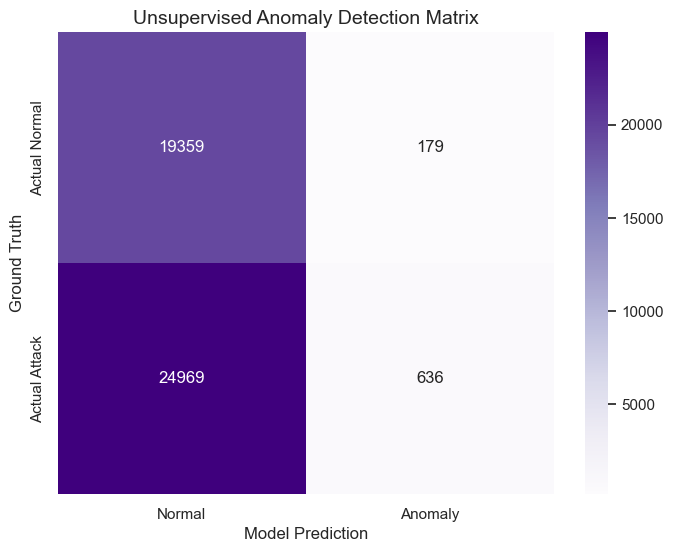

In [7]:
# 4. Evaluate on Mixed Test Data
print("\nScoring Test Data for Anomalies...")
# The model returns 1 for inliers (Normal) and -1 for outliers (Anomalies)
raw_preds = iso_forest.predict(X_test)
# Map the predictions to match our standard target format:
# Normal (1) becomes 0. Anomaly (-1) becomes 1.
anomaly_preds = np.where(raw_preds == 1, 0, 1)
print("\n--- Isolation Forest Performance on Zero-Day Simulation ---")
print(classification_report(y_test, anomaly_preds, target_names=['Normal Baseline', 'Flagged Anomaly']))
# Plot Confusion Matrix
cm = confusion_matrix(y_test, anomaly_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Normal', 'Anomaly'], yticklabels=['Actual Normal', 'Actual Attack'])
plt.title('Unsupervised Anomaly Detection Matrix', fontsize=14)
plt.ylabel('Ground Truth')
plt.xlabel('Model Prediction')
plt.show()

In [8]:
# 5. Save the Anomaly Model
model_path = f'{MODELS_DIR}isolation_forest_detector.pkl'
joblib.dump(iso_forest, model_path)
print(f"\nPipeline Complete! Unsupervised model saved to: {model_path}")


Pipeline Complete! Unsupervised model saved to: C:/Users/SATWIK GHOSH/OneDrive/Desktop/AI-Powered Cyberthreat Analyzer/models/isolation_forest_detector.pkl


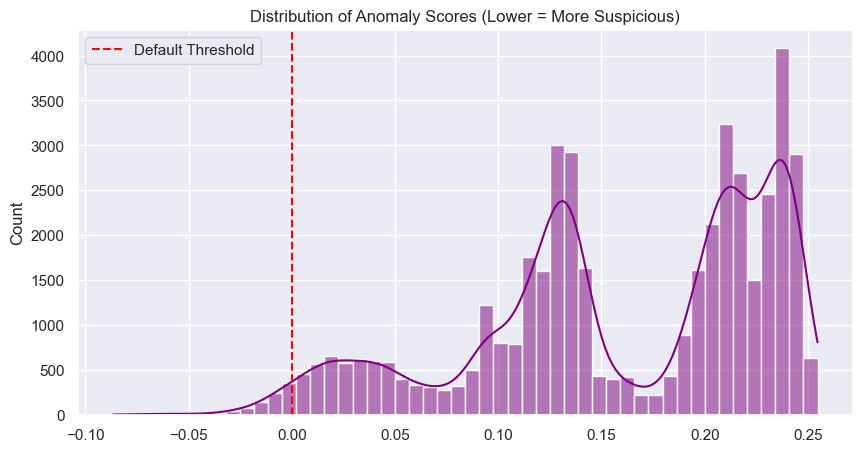


Average Anomaly Score by Class:
label
0    0.183917
1    0.141637
Name: score, dtype: float64


In [9]:
# 6. Manual Threshold Tuning (The Fix)
# Get raw anomaly scores (lower means MORE anomalous)
scores = iso_forest.decision_function(X_test)

plt.figure(figsize=(10, 5))
sns.histplot(scores, bins=50, kde=True, color='purple')
plt.title('Distribution of Anomaly Scores (Lower = More Suspicious)')
plt.axvline(x=0, color='red', linestyle='--', label='Default Threshold')
plt.legend()
plt.show()

# Proving it works: Let's see if DDoS scores are at least SLIGHTLY lower than Benign
results_df = pd.DataFrame({'score': scores, 'label': y_test.values})
print("\nAverage Anomaly Score by Class:")
print(results_df.groupby('label')['score'].mean())